# Support Vector Machine

Support Vector Machine (SVM) is a very powerful and versatile Machine Learning model developed in the 1990s and is capable of performing linear or nonlinear classification, regression, and even outlier detection. SVMs are particularly well suited for classification of complex but small- or medium-sized datasets.

## Support Vector Regressor

Support Vector Regressor trains the model that includes as many vectors as possible inside the margin. The model penalizes for vectors that lie outside the margin and not penalize the vectors that reside inside the margin. Cost function would be the well-loss.

Optimisation of width takes the form of

$$
\min \frac{1}{2} ||w||^2 + C \sum_{i=1}^{n} (\zeta_i + \zeta_i^*)
$$

subject to,

$$
y_i - w \cdot x_i - b \leq \epsilon + \zeta_i
$$

$$
w \cdot x_i + b - y_i \leq \epsilon + \zeta_i^*
$$

$$
\zeta_i, \zeta_i^* \geq 0
$$

The degree of violations are controlled by the hyperparameter \( C \) and the magnitude of the penalty for each vector is proportional to the slack variable \( \zeta_i \).

## Kernel Trick

Kernel is a function that creates the implicit mapping or projection to a higher dimensional space and is used to find relations in dataset. Kernel methods are named after kernel functions, which enable them to operate in a high-dimensional feature space. The Kernel computes the inner products rather than computing the coordinates of the data and this approach is popularly called as the kernel trick. The popular choices of kernels are

| Kernel Name    | Keyword Argument | Keyword Argument |
|---------------|-----------------|-----------------|
| **Linear Kernel** | `linear` | $$ (x_i, x_j) $$ |
| **Polynomial** | `poly` | $$ (x_i + x_j)^d $$ |
| **Gaussian RBF** | `rbf` | $$ e^{-\gamma ||x_i - x_j||^2} $$ |
| **Sigmoid** | `sigmoid` | $$ \tanh(\sigma x_i \cdot x_j + r) $$ |

Using a hyperplane to separate the two classes will have limited performance as most problems require a non-linear decision boundary. We employ the kernel trick to overcome this limitation to engineer non-linear features using the original features. The advantage of using a kernel trick are

- No direct feature generation that increases the size of the data set.
- We can swap out any of different kernels to see which one performs the best.


# SVM Implementation

## Import Libraries

In [1]:
# Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
# Preprocessing
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
# SVM
from sklearn.svm import SVR
# Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Retrive Data

In [2]:
# Create a variable to predict for 'n' days
n = 5

In [3]:
# Load locally stored data
df = pd.read_csv('spy.csv', index_col=0, parse_dates=True)
df = df[['Adj Close']]
# Check first 5 values
df.tail()

,Adj Close
Date,
2020-04-23,279.079987
2020-04-24,282.970001
2020-04-27,287.049988
2020-04-28,285.730011
2020-04-29,293.209991


In [4]:
df['Target'] = df['Adj Close'].shift(-n)
df.tail(6)

,Adj Close,Target
Date,,
2020-04-22,279.100006,293.209991
2020-04-23,279.079987,NaN
2020-04-24,282.970001,NaN
2020-04-27,287.049988,NaN
2020-04-28,285.730011,NaN
2020-04-29,293.209991,NaN


## Feature Specification

Features or Predictors are also known as an independent variable which are used to determine the value of the target variable. We will use just the close price as our feature.

In [5]:
# Predictors
X = df[['Adj Close']].values[:-n]
X

array([[100.37689972],
       [ 99.3944931 ],
       [ 95.50753021],
       ...,
       [281.58999634],
       [273.04000854],
       [279.1000061 ]])

In [6]:
X.shape # Predictors should be of 2D

(5109, 1)

## Define Label

Label or the target variable is also known as the dependent variable. Here, the target variable is n-days lagged SPY price.

In [7]:
y = df['Target'].values[:-n]
# Check the output
y

array([ 99.60805511,  99.94975281,  98.7537384 , ..., 287.04998779,
       285.73001099, 293.20999146])

In [8]:
y.shape # Target Label should be 1D

(5109,)

## Split Data

In [9]:
# Splitting the datasets into training and testing data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, shuffle=False)
# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 4087, 1022


## Fit Model

We will now create and train the SVM (Regessor). All the feature and label should have a similar scale and the scaling can be accomplished by using the MinMaxScaler transformer.

In [10]:
# Scale and fit the model using pipeline
# pipe = Pipeline([("scaler", MinMaxScaler()), ("regressor", SVR(C=1, gamma='auto', kernel='linear'))])
pipe = Pipeline([("scaler", MinMaxScaler()), ("regressor", SVR(kernel='rbf', C=1e3, gamma=0.1))])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', SVR(C=1000.0, gamma=0.1))])

## Predict Model

In [11]:
# Predicting the test dataset
y_pred = pipe.predict(X_test)
y_pred[-5:]

array([263.44766805, 268.3800078 , 265.10182129, 259.31924611,
       263.44766805])

In [12]:
# Metrics
pipe.score(X_test,y_test) # r2_score(y_test,y_pred)

0.8278931536996095

In [13]:
# Output prediction scoare
print(f'Train Accuracy: {pipe.score(X_train,y_train):0.4}')
print(f'Test Accuracy: {pipe.score(X_test,y_test):0.4}')

Train Accuracy: 0.9949
Test Accuracy: 0.8279


## Hyperparameter Tuning

Now, let's perform hyperparameter tuning using Gridsearch

In [14]:
# Cross-validation
tscv = TimeSeriesSplit(n_splits=5)

In [15]:
# Get parameters list
pipe.get_params()

{'memory': None,
 'steps': [('scaler', MinMaxScaler()),
  ('regressor', SVR(C=1000.0, gamma=0.1))],
 'transform_input': None,
 'verbose': False,
 'scaler': MinMaxScaler(),
 'regressor': SVR(C=1000.0, gamma=0.1),
 'scaler__clip': False,
 'scaler__copy': True,
 'scaler__feature_range': (0, 1),
 'regressor__C': 1000.0,
 'regressor__cache_size': 200,
 'regressor__coef0': 0.0,
 'regressor__degree': 3,
 'regressor__epsilon': 0.1,
 'regressor__gamma': 0.1,
 'regressor__kernel': 'rbf',
 'regressor__max_iter': -1,
 'regressor__shrinking': True,
 'regressor__tol': 0.001,
 'regressor__verbose': False}

In [16]:
# Perform Gridsearch and fit
param_grid = {"regressor__C": [0.1, 1, 10, 100, 1000],
              "regressor__kernel": ["poly", "rbf", "sigmoid"],
              "regressor__gamma": [1e-7, 1e-4, 1e-3, 1e-2]}
gs = GridSearchCV(pipe, param_grid, n_jobs=-1, cv=tscv, verbose=1)
gs.fit(X_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('regressor',
                                        SVR(C=1000.0, gamma=0.1))]),
             n_jobs=-1,
             param_grid={'regressor__C': [0.1, 1, 10, 100, 1000],
                         'regressor__gamma': [1e-07, 0.0001, 0.001, 0.01],
                         'regressor__kernel': ['poly', 'rbf', 'sigmoid']},
             verbose=1)

In [17]:
# Best Estimator
gs.best_estimator_

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('regressor', SVR(C=1000, gamma=0.01, kernel='sigmoid'))])

In [18]:
# Best Params
params = gs.best_params_
params

{'regressor__C': 1000,
 'regressor__gamma': 0.01,
 'regressor__kernel': 'sigmoid'}

In [19]:
# Best Score
# Mean cross-validated score of the best_estimator
gs.best_score_

0.9577357220585366

In [20]:
# Predicting the test dataset
y_preds = gs.predict(X_test)
y_preds[-5:]

array([279.8523288 , 287.41181837, 282.34875914, 273.77663046,
       279.8523288 ])

In [21]:
# Output prediction scoare
print(f'Train Accuracy\t: {gs.score(X_train,y_train):0.6}')
print(f'Test Accuracy\t: {gs.score(X_test,y_test):0.6}')

Train Accuracy	: 0.994864
Test Accuracy	: 0.969009


## Visualize

Let's now visualize the real, predicted values and the spread between them.

In [22]:
# Create a dataframe to subsume key values
df3 = pd.DataFrame({'X': X_test.flatten(), 'y': y_preds})
df3['X'] = df3['X'].shift(-n)
df3['X-y'] = df3['X'] - df3['y']
df3 = df3[:-n]
df3.tail(n)

,X,y,X-y
1012,279.100006,274.769188,4.330818
1013,286.640015,278.950006,7.690009
1014,281.589996,276.403418,5.186578
1015,273.040009,284.554456,-11.514447
1016,279.100006,278.508864,0.591142


In [23]:
# Check for missing values
df3.isnull().sum()

X      0
y      0
X-y    0
dtype: int64

In [24]:
# Mean difference
print(f'Mean Difference\t: {np.mean(df3["X-y"]):0.4}')

Mean Difference	: -0.2387


Text(0.5, 1.0, 'Histogram of Residual of x+5 and y_preds')

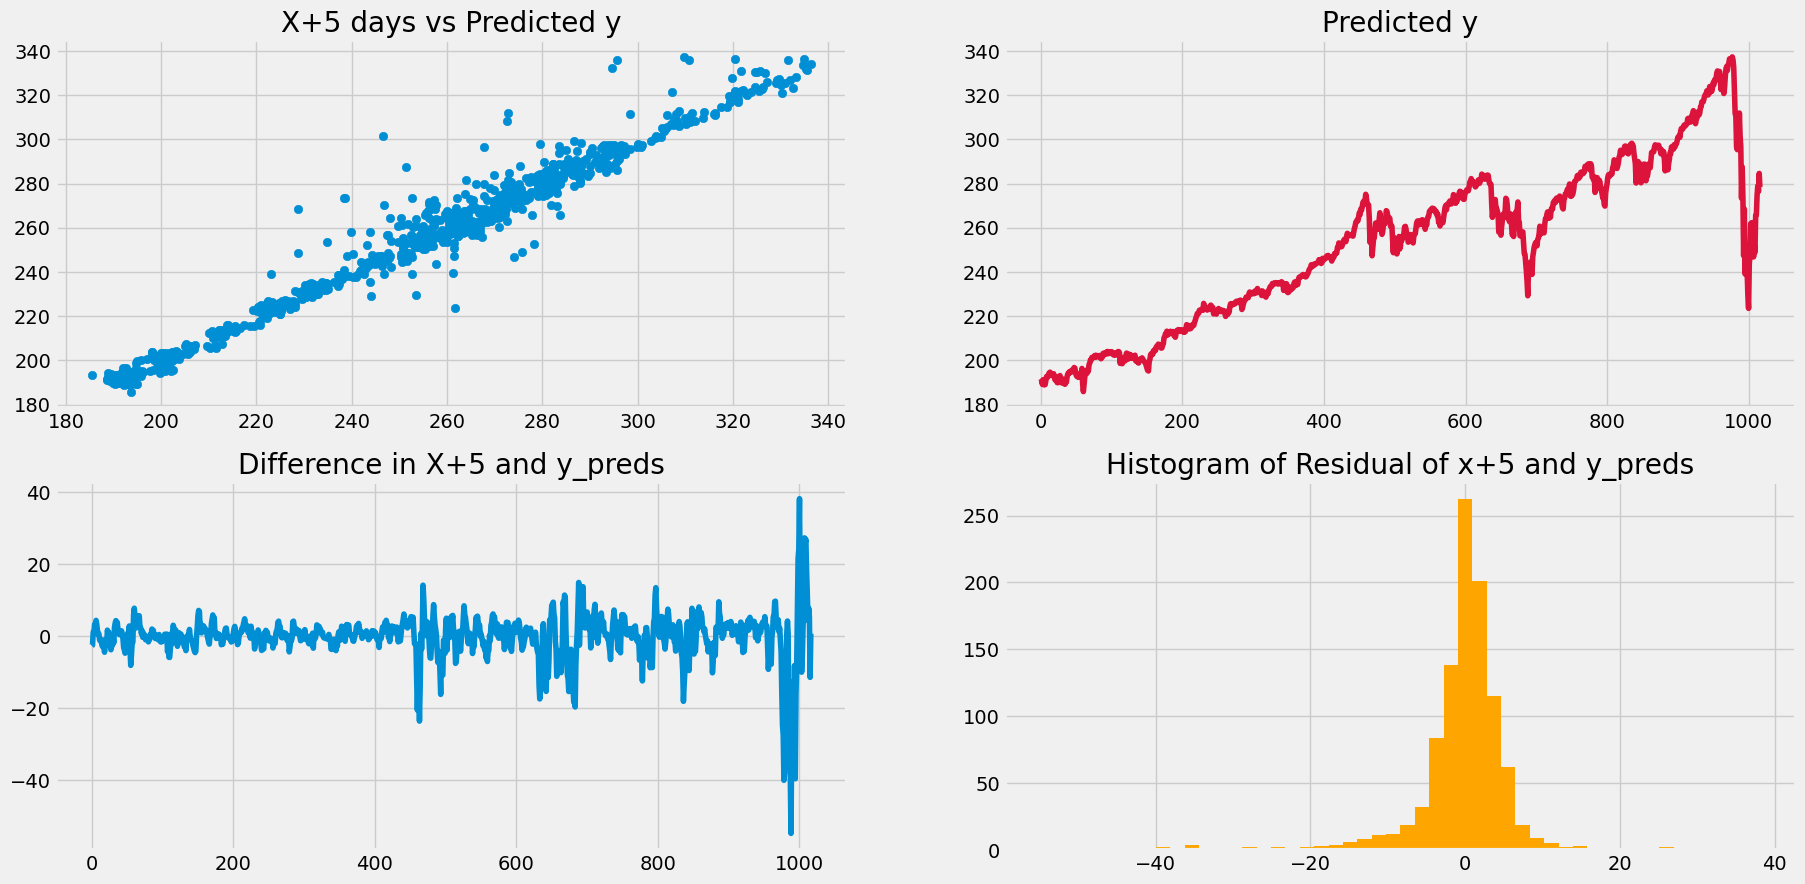

In [25]:
# Plot x+5 vs y_pred
fig, ax = plt.subplots(2,2, figsize=(20,10))
ax[0,0].scatter(df3['X'], df3['y'])
ax[0,0].set_title('X+5 days vs Predicted y')
# # Plot Predicted Price
ax[0,1].plot(df3.index, y_preds[:-n], 'crimson')
ax[0,1].set_title('Predicted y')
# # Plot Residual of x+5 and y_pred
ax[1,0].plot(df3.index, df3['X-y'])
ax[1,0].set_title('Difference in X+5 and y_preds')
# # Plot Histogram of Residual of x+5 and y_pred
ax[1,1].hist(df3['X-y'], bins=50, density=False, color='orange')
ax[1,1].set_title('Histogram of Residual of x+5 and y_preds')